In [1]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
base = '/content/drive/MyDrive/UniAthleteIQ'

for root, dirs, files in os.walk(base):
  level = root.replace(base, ' ').count(os.sep)
  indent = '    ' * level
  print(f'{indent}📁 {os.path.basename(root)}/')
  for file in files:
    print(f'{indent}  📄{file}')

📁 UniAthleteIQ/
    📁 notebooks/
      📄01_data_exploration.ipynb
    📁 datasets/
      📄sports_injury_detection_dataset.csv
      📄NBA Player Injury Stats(1951 - 2023).csv
      📄week_approach_maskedID_timeseries.csv
      📄day_approach_maskedID_timeseries.csv
      📄basketball_injury_biomechanical_dataset.csv
      📄dataset.csv
    📁 outputs/
        📁 charts/
        📁 models/
    📁 paper/
        📁 references/


In [ ]:
import pandas as pd

files = {
    "Multi-Sport"      : "/content/drive/MyDrive/UniAthleteIQ/datasets/sports_injury_detection_dataset.csv",
    "NBA Injuries"     : "/content/drive/MyDrive/UniAthleteIQ/datasets/NBA Player Injury Stats(1951 - 2023).csv",
    "Basketball Bio"   : "/content/drive/MyDrive/UniAthleteIQ/datasets/basketball_injury_biomechanical_dataset.csv",
    "Runners Daily"    : "/content/drive/MyDrive/UniAthleteIQ/datasets/day_approach_maskedID_timeseries.csv",
    "Runners Weekly"   : "/content/drive/MyDrive/UniAthleteIQ/datasets/week_approach_maskedID_timeseries.csv",
    "Extra Dataset"    : "/content/drive/MyDrive/UniAthleteIQ/datasets/dataset.csv",
}

for name, path in files.items():
    print(f"\n{'='*60}")
    print(f"DATASET: {name}")
    print(f"{'='*60}")
    try:
        df = pd.read_csv(path)
        print(f"✅ Rows       : {df.shape[0]}")
        print(f"✅ Columns    : {df.shape[1]}")
        print(f"📋 Column Names: {list(df.columns)}")
        print(f"\n🔍 First 2 rows:\n{df.head(2)}")
        print(f"\n⚠️ Missing Values:\n{df.isnull().sum()}")
    except Exception as e:
        print(f"❌ ERROR: {e}")


DATASET: Multi-Sport
✅ Rows       : 1000
✅ Columns    : 13
📋 Column Names: ['Athlete_ID', 'Sport_Type', 'Session_Date', 'Heart_Rate_BPM', 'Respiratory_Rate_BPM', 'Skin_Temperature_C', 'Blood_Oxygen_Level_Percent', 'Impact_Force_Newtons', 'Cumulative_Fatigue_Index', 'Activity_Type', 'Duration_Minutes', 'Injury_Risk_Score', 'Injury_Occurred']

🔍 First 2 rows:
  Athlete_ID  Sport_Type Session_Date  Heart_Rate_BPM  Respiratory_Rate_BPM  \
0      A0001  Basketball   2024-01-01             151                    20   
1      A0002      Tennis   2024-01-02             114                    20   

   Skin_Temperature_C  Blood_Oxygen_Level_Percent  Impact_Force_Newtons  \
0           37.435984                   95.499334            135.269735   
1           36.859562                   98.440222            147.727352   

   Cumulative_Fatigue_Index Activity_Type  Duration_Minutes  \
0                  0.481415       Jumping                22   
1                  0.757133       Running        

In [ ]:
import pandas as pd
import numpy as np

# ── Load all 4 usable datasets ──────────────────────────────

df_multi = pd.read_csv('/content/drive/MyDrive/UniAthleteIQ/datasets/sports_injury_detection_dataset.csv')

df_runners_day = pd.read_csv('/content/drive/MyDrive/UniAthleteIQ/datasets/day_approach_maskedID_timeseries.csv')

df_runners_week = pd.read_csv('/content/drive/MyDrive/UniAthleteIQ/datasets/week_approach_maskedID_timeseries.csv')

df_football = pd.read_csv('/content/drive/MyDrive/UniAthleteIQ/datasets/dataset.csv')

print("✅ All datasets loaded successfully!")

# ── DATASET 1: Multi-Sport ───────────────────────────────────
df1 = df_multi[['Heart_Rate_BPM', 'Cumulative_Fatigue_Index',
                 'Duration_Minutes', 'Injury_Risk_Score',
                 'Injury_Occurred', 'Sport_Type']].copy()
df1.columns = ['heart_rate', 'fatigue_index',
               'duration_minutes', 'injury_risk_score',
               'injury_occurred', 'sport']
df1['sport'] = df_multi['Sport_Type']

# ── DATASET 2: Runners Daily ─────────────────────────────────
df2 = df_runners_day[['total km', 'perceived exertion',
                       'perceived recovery', 'injury']].copy()
df2.columns = ['duration_minutes', 'fatigue_index',
               'injury_risk_score', 'injury_occurred']
df2['heart_rate'] = np.nan
df2['sport'] = 'Athletics'

# ── DATASET 3: Runners Weekly ────────────────────────────────
df3 = df_runners_week[['total kms', 'avg exertion',
                        'avg recovery', 'injury']].copy()
df3.columns = ['duration_minutes', 'fatigue_index',
               'injury_risk_score', 'injury_occurred']
df3['heart_rate'] = np.nan
df3['sport'] = 'Athletics'

# ── DATASET 4: Football ──────────────────────────────────────
df4 = df_football[['age', 'bmi', 'season_days_injured',
                    'season_minutes_played',
                    'significant_injury_prev_season']].copy()
# Convert days injured → binary label (injured = 1 if days > 0)
df4['injury_occurred'] = (df_football['season_days_injured'] > 0).astype(int)
df4['heart_rate'] = np.nan
df4['fatigue_index'] = np.nan
df4['injury_risk_score'] = np.nan
df4['duration_minutes'] = df_football['season_minutes_played']
df4['sport'] = 'Football'

# ── COMBINE ALL ──────────────────────────────────────────────
common_cols = ['heart_rate', 'fatigue_index', 'duration_minutes',
               'injury_risk_score', 'injury_occurred', 'sport']

df_combined = pd.concat([
    df1[common_cols],
    df2[common_cols],
    df3[common_cols],
    df4[common_cols]
], ignore_index=True)

# ── FILL MISSING VALUES ──────────────────────────────────────
df_combined['heart_rate'].fillna(df_combined['heart_rate'].median(), inplace=True)
df_combined['fatigue_index'].fillna(df_combined['fatigue_index'].median(), inplace=True)
df_combined['injury_risk_score'].fillna(df_combined['injury_risk_score'].median(), inplace=True)
df_combined['duration_minutes'].fillna(df_combined['duration_minutes'].median(), inplace=True)

# ── ENCODE SPORT COLUMN ──────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_combined['sport_encoded'] = le.fit_transform(df_combined['sport'])

# ── SAVE COMBINED DATASET ────────────────────────────────────
output_path = '/content/drive/MyDrive/UniAthleteIQ/datasets/combined_dataset.csv'
df_combined.to_csv(output_path, index=False)

print(f"\n✅ Combined Dataset Summary:")
print(f"Total Rows    : {df_combined.shape[0]}")
print(f"Total Columns : {df_combined.shape[1]}")
print(f"\nSport Distribution:\n{df_combined['sport'].value_counts()}")
print(f"\nInjury Label Distribution:\n{df_combined['injury_occurred'].value_counts()}")
print(f"\nMissing Values:\n{df_combined.isnull().sum()}")
print(f"\n✅ Saved to Drive!")

✅ All datasets loaded successfully!


/tmp/ipykernel_1884/2153416934.py:65: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_combined['heart_rate'].fillna(df_combined['heart_rate'].median(), inplace=True)
/tmp/ipykernel_1884/2153416934.py:66: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col


✅ Combined Dataset Summary:
Total Rows    : 87865
Total Columns : 7

Sport Distribution:
sport
Athletics     85564
Football       1503
Tennis          215
Basketball      204
Soccer          198
Baseball        181
Name: count, dtype: int64

Injury Label Distribution:
injury_occurred
0    84790
1     3075
Name: count, dtype: int64

Missing Values:
heart_rate           0
fatigue_index        0
duration_minutes     0
injury_risk_score    0
injury_occurred      0
sport                0
sport_encoded        0
dtype: int64

✅ Saved to Drive!


✅ Loaded: 87865 rows, 7 columns

✅ After SMOTE:
Not Injured (0): 84790
Injured     (1): 84790

✅ Train size: 135664
✅ Test size : 33916

  Logistic Regression
  Accuracy  : 0.8069
  F1 Score  : 0.7625
  Precision : 0.9906
  Recall    : 0.6198

  Random Forest
  Accuracy  : 0.9638
  F1 Score  : 0.9629
  Precision : 0.9871
  Recall    : 0.9399

  XGBoost
  Accuracy  : 0.9254
  F1 Score  : 0.9202
  Precision : 0.9888
  Recall    : 0.8605


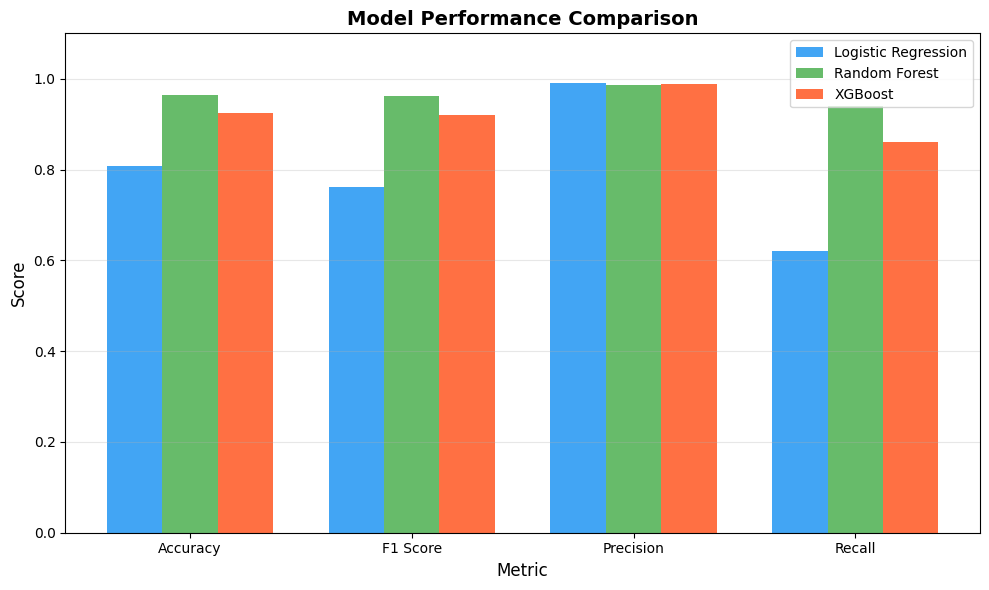

✅ Chart 1 saved!


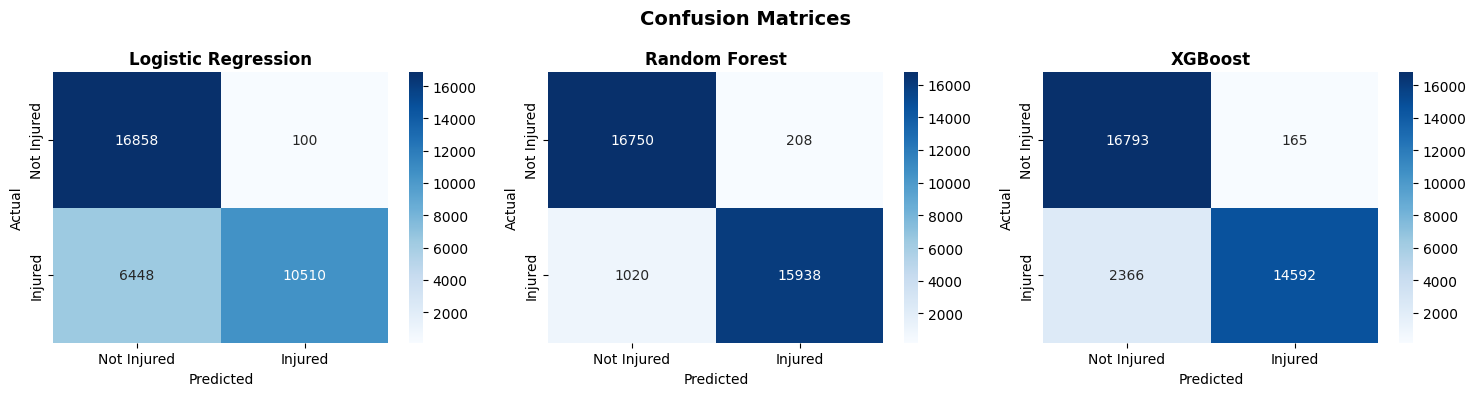

✅ Chart 2 saved!


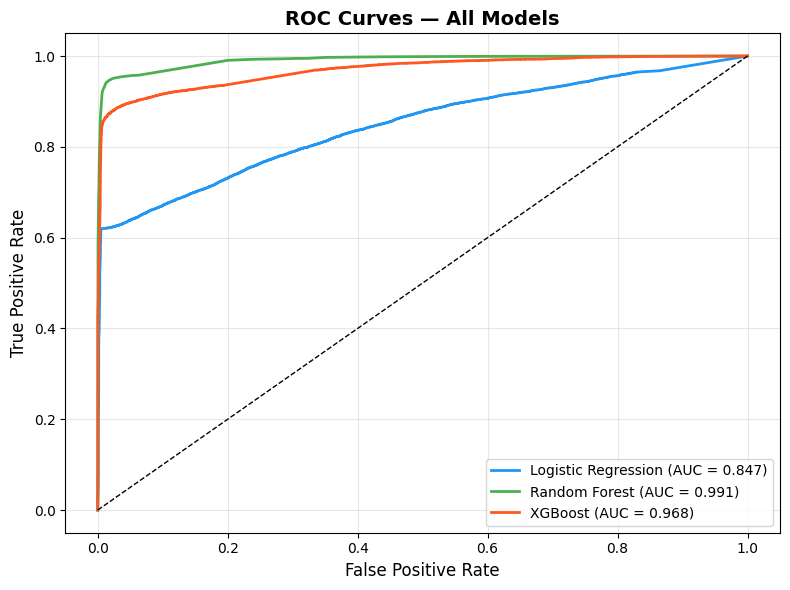

✅ Chart 3 saved!


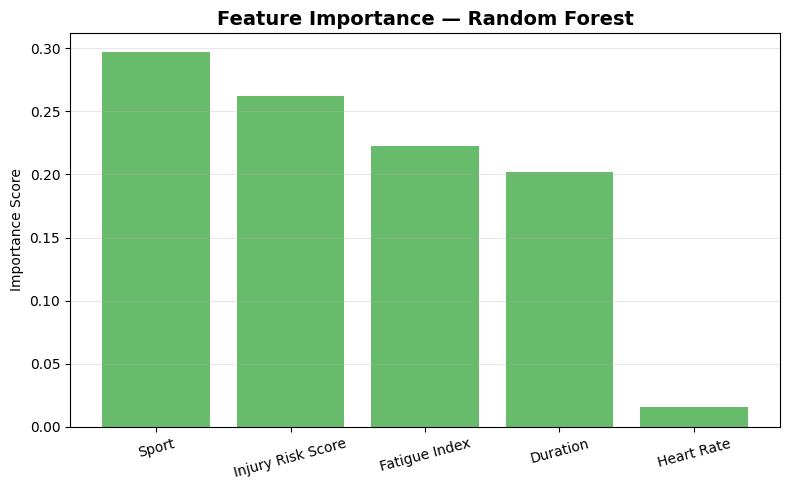

✅ Chart 4 saved!

🎉 ALL DONE! All charts saved to Drive!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, f1_score,
                             precision_score, recall_score,
                             confusion_matrix, roc_curve, auc,
                             classification_report)
from imblearn.over_sampling import SMOTE

# ── Load Combined Dataset ────────────────────────────────────
df = pd.read_csv('/content/drive/MyDrive/UniAthleteIQ/datasets/combined_dataset.csv')
print(f"✅ Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# ── Features & Target ────────────────────────────────────────
X = df[['heart_rate', 'fatigue_index', 'duration_minutes',
        'injury_risk_score', 'sport_encoded']]
y = df['injury_occurred']

# ── Fix Imbalance Using SMOTE ────────────────────────────────
# SMOTE creates synthetic samples of minority class (injured=1)
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(f"\n✅ After SMOTE:")
print(f"Not Injured (0): {sum(y_balanced==0)}")
print(f"Injured     (1): {sum(y_balanced==1)}")

# ── Scale Features ───────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_balanced)

# ── Train/Test Split (80/20) ─────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_balanced,
    test_size=0.2, random_state=42, stratify=y_balanced)

print(f"\n✅ Train size: {X_train.shape[0]}")
print(f"✅ Test size : {X_test.shape[0]}")

# ── Train 3 Models ───────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model'    : model,
        'y_pred'   : y_pred,
        'accuracy' : accuracy_score(y_test, y_pred),
        'f1'       : f1_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall'   : recall_score(y_test, y_pred),
    }
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {results[name]['accuracy']:.4f}")
    print(f"  F1 Score  : {results[name]['f1']:.4f}")
    print(f"  Precision : {results[name]['precision']:.4f}")
    print(f"  Recall    : {results[name]['recall']:.4f}")

# ── Chart 1: Model Comparison Bar Chart ─────────────────────
metrics = ['accuracy', 'f1', 'precision', 'recall']
model_names = list(results.keys())
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF5722']
for i, (name, res) in enumerate(results.items()):
    vals = [res[m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'F1 Score', 'Precision', 'Recall'])
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UniAthleteIQ/outputs/charts/model_comparison.png', dpi=150)
plt.show()
print("✅ Chart 1 saved!")

# ── Chart 2: Confusion Matrices ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Injured','Injured'],
                yticklabels=['Not Injured','Injured'])
    ax.set_title(name, fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UniAthleteIQ/outputs/charts/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Chart 2 saved!")

# ── Chart 3: ROC Curves ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#4CAF50', '#FF5722']
for (name, res), color in zip(results.items(), colors):
    y_prob = res['model'].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')
ax.plot([0,1],[0,1],'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UniAthleteIQ/outputs/charts/roc_curves.png', dpi=150)
plt.show()
print("✅ Chart 3 saved!")

# ── Chart 4: Feature Importance (Random Forest) ─────────────
feature_names = ['Heart Rate', 'Fatigue Index',
                 'Duration', 'Injury Risk Score', 'Sport']
rf_model = results['Random Forest']['model']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(range(len(importances)),
       importances[indices],
       color='#4CAF50', alpha=0.85)
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([feature_names[i] for i in indices], rotation=15)
ax.set_title('Feature Importance — Random Forest',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Importance Score')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/UniAthleteIQ/outputs/charts/feature_importance.png', dpi=150)
plt.show()
print("✅ Chart 4 saved!")

print("\n🎉 ALL DONE! All charts saved to Drive!")